In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


### making a non linear dummy data using np

In [3]:
X =10*np.random.rand(100, 1) - 5.5 #picking 100 random nos. from 1 - 100
y=0.5*X**2+ 1.5*X + np.random.randn(100, 1) #making a random y for each X


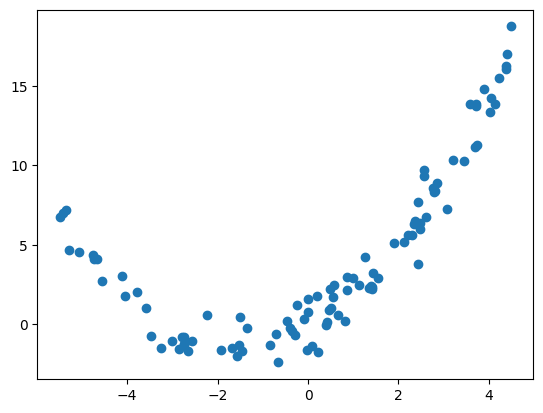

In [4]:
plt.scatter(X, y)
plt.show()

In [5]:
# Train test split 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Applying LR
from sklearn.linear_model import LinearRegression

regression = LinearRegression()
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


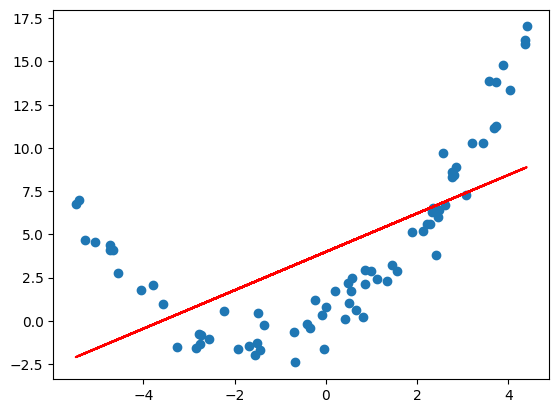

In [6]:
# plot for simple LR:
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train), color="red")
# We can see there's a lot of error we can also verify the same using r2 score.abs

In [7]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error
y_pred=regression.predict(X_test)
mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MSE: ", mse)

# R-sq score:
from sklearn.metrics import r2_score
r_sq=r2_score(y_test, y_pred)
print("R-sq. :", r_sq)

# Adj r-sq value:
adj_r_sq= 1-(1-r_sq)*(len(y_test)-1)/(len(y_test)- X_test.shape[1] -1)
print("Adj R-sq :", adj_r_sq)

# from this we can see the model performs poorly in simple LR.


RMSE:  4.643298369575553
MAE:  4.066519792612978
MSE:  21.56021974890299
R-sq. : 0.4446880568499725
Adj R-sq : 0.42054405932171046


In [8]:
# Applying the polyn tx :
from sklearn.preprocessing import PolynomialFeatures
polyn=PolynomialFeatures(degree=2, include_bias=True)
X_train_poly=polyn.fit_transform(X_train)
X_test_poly=polyn.transform(X_test)


In [12]:
from sklearn.metrics import r2_score
regression=LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred= regression.predict(X_test_poly)
score=r2_score( y_test,y_pred)
print(score)


0.9650077864650326


In [14]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error
y_pred=regression.predict(X_test_poly)
mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MSE: ", mse)

# R-sq score:
from sklearn.metrics import r2_score
r_sq=r2_score(y_test, y_pred)
print("R-sq. :", r_sq)

# Adj r-sq value:
adj_r_sq= 1-(1-r_sq)*(len(y_test)-1)/(len(y_test)- X_test_poly.shape[1] -1)
print("Adj R-sq :", adj_r_sq)

# from this we can see the model performs well in polynomial LR.


RMSE:  1.16558457767324
MAE:  1.0191282583331023
MSE:  1.3585874077097053
R-sq. : 0.9650077864650326
Adj R-sq : 0.9600088988171801


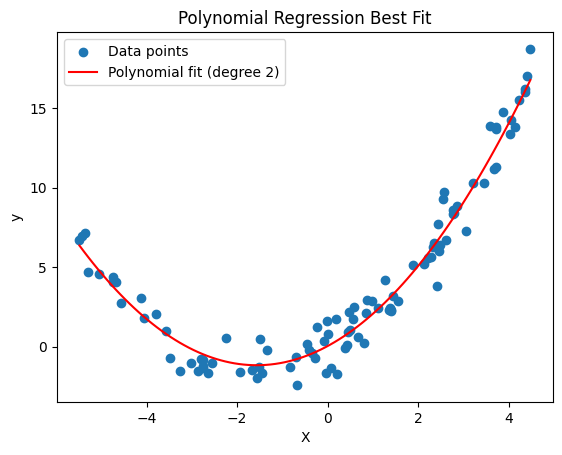

In [17]:


# Generate a range of X values for smooth plotting
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# Transform to polynomial features
X_plot_poly = polyn.transform(X_plot)

# Predict using the polynomial regression model
y_plot = regression.predict(X_plot_poly)

# Plot the original data points
plt.scatter(X, y, label='Data points')

# Plot the best fit polynomial curve
plt.plot(X_plot, y_plot, color='red', label='Polynomial fit (degree 2)')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Regression Best Fit')
plt.legend()
plt.show()

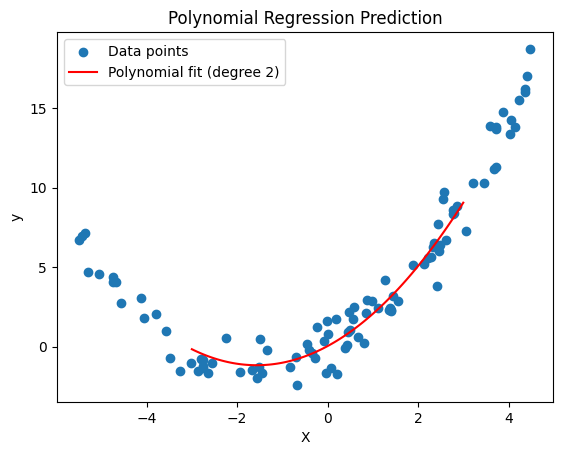

In [23]:
# New data point prediction:
X_new= np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly=polyn.transform(X_new)
y_new_pred=regression.predict(X_new_poly)   
plt.scatter(X, y, label='Data points')
plt.plot(X_new, y_new_pred, color='red', label='Polynomial fit (degree 2)')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Regression Prediction')
plt.legend()
plt.show()

